In [1]:
from langgraph.graph import StateGraph, START, END


Typed Dict

In [21]:
from typing import TypedDict


In [3]:
class SimpleTDState(TypedDict):
    a: int
    b: int
    result: int

In [4]:
def td_node(state: SimpleTDState) -> SimpleTDState:
    state['result'] = state['a'] ** state['b']
    return state

In [5]:
td_graph_builder = StateGraph(SimpleTDState)
td_graph_builder.add_node("tdnode", td_node)
td_graph_builder.add_edge(START, "tdnode")
td_graph_builder.add_edge("tdnode", END)
td_graph = td_graph_builder.compile()

In [6]:
from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

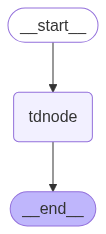

In [7]:
display_graph(td_graph)


In [8]:
td_graph.invoke(SimpleTDState(a=10,b=2, result=0))


{'a': 10, 'b': 2, 'result': 100}

In [9]:
td_graph.invoke(SimpleTDState(a="hello",b=2, result=0))


TypeError: unsupported operand type(s) for ** or pow(): 'str' and 'int'

Dataclasses

In [10]:
from dataclasses import dataclass


In [11]:

@dataclass
class SimpleDCState:
    a: int
    b: int
    result: int = 0

In [12]:
dc_graph_builder = StateGraph(SimpleDCState)


In [13]:

def dc_node(state:SimpleDCState) -> SimpleDCState:
    state.result = state.a ** state.b
    return state

In [14]:
dc_graph_builder.add_node("dcnode", dc_node)
dc_graph_builder.add_edge(START, "dcnode")
dc_graph_builder.add_edge("dcnode", END)
dc_graph = dc_graph_builder.compile()

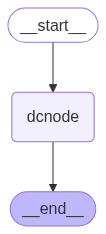

In [15]:
display_graph(dc_graph)


In [16]:
dc_graph.invoke(SimpleDCState(a=10, b=2, result=0))


{'a': 10, 'b': 2, 'result': 100}

In [17]:
dc_graph.invoke(SimpleDCState(a="hello", b=2, result=0))


TypeError: unsupported operand type(s) for ** or pow(): 'str' and 'int'

Pydantic

In [18]:
from pydantic import BaseModel


In [2]:
from pydantic import BaseModel

In [20]:
class SimpleyPyState(BaseModel):
    a: int
    b: int
    result: int = 0

In [24]:
pd_graph_builder = StateGraph(SimpleyPyState)


In [22]:
def pd_node(state: SimpleyPyState) -> SimpleyPyState:
    state.result= state.a**state.b
    return state

In [25]:
pd_graph_builder.add_node("pdnode", pd_node)
pd_graph_builder.add_edge(START, "pdnode")
pd_graph_builder.add_edge("pdnode", END)
pd_graph = pd_graph_builder.compile()

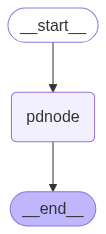

In [26]:
display_graph(pd_graph)

In [27]:
pd_graph.invoke(SimpleyPyState(a=10,b=2))

{'a': 10, 'b': 2, 'result': 100}

In [ ]:
pd_graph.invoke(SimpleyPyState(a="Hello", b=2))


ValidationError: 1 validation error for SimpleyPyState
a
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='Hello', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/int_parsing

In [30]:
%pip install pydantic[email]



   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ------------------------------------

In [1]:
from pydantic import EmailStr, AnyUrl, Field, field_validator

In [4]:
class businessstate(BaseModel):
    name: str = Field(...,min_length=5)
    email: EmailStr
    mobile: str = Field(min_length=10, default="+919515151992")
    website: AnyUrl
    category: str=Field(default="education", min_length=1)

    @field_validator("category")
    def is_valid_category(cls,value):
        if value.lower() not in ["education", "sports"]:
            raise ValueError("Inva;id category, as of now only education and sports are valid")
        return value

In [5]:
def node(state: businessstate) ->businessstate:
    return state

In [8]:
from langgraph.graph import StateGraph, START, END


In [9]:

business_graph_builder = StateGraph(businessstate)
business_graph_builder.add_node("test", node)
business_graph_builder.add_edge(START, "test")
business_graph_builder.add_edge("test", END)
business_graph = business_graph_builder.compile()

In [14]:

from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

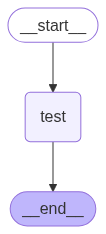

In [15]:
display_graph(business_graph)


In [17]:

valid_state = businessstate(
    name="qualitythought",
    email="info@qualitythought.in",
    website="https://qualitythought.in",
    category="education"

)
business_graph.invoke(valid_state)

{'name': 'qualitythought',
 'email': 'info@qualitythought.in',
 'mobile': '+919515151992',
 'website': AnyUrl('https://qualitythought.in/'),
 'category': 'education'}

In [19]:

invalid_state = businessstate(
    name="qualitythoughtresorts",
    email="info@qualitythought.in",
    website="https://qualitythought.in",
    category="hospitality"
)
business_graph.invoke(invalid_state)

ValidationError: 1 validation error for businessstate
category
  Value error, Inva;id category, as of now only education and sports are valid [type=value_error, input_value='hospitality', input_type=str]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error

In [ ]:

class NumberGameState(TypedDict):
    guess: int
    result: str = ""

In [23]:
class ResultState(TypedDict):
    guess: int
    actual: int
    result: str

In [24]:
def play(state: NumberGameState) -> ResultState:
    return ResultState(guess=state['guess'], actual=1, result='lost')

In [25]:
def declare(state: ResultState) -> NumberGameState:
    return NumberGameState(guess=state['guess'], result=state['result'])


In [26]:

game_graph_builder=StateGraph(NumberGameState)
game_graph_builder.add_node("play", play)
game_graph_builder.add_node("verify", declare)
game_graph_builder.add_edge(START, "play")
game_graph_builder.add_edge("play", "verify")
game_graph_builder.add_edge("verify", END)
game_graph = game_graph_builder.compile()

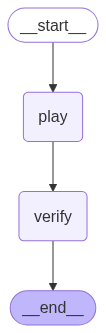

In [28]:
display_graph(game_graph)


In [29]:
game_graph.invoke(NumberGameState(guess=3))


{'guess': 3, 'result': 'lost'}